In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

sns.set_style("whitegrid")
df = pd.read_csv("datasets_11167_15520_train.csv")
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [2]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget distribution:\n", df["price_range"].value_counts().sort_index())

Shape: (2000, 21)

Data types:
 battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object

Missing values:
 battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


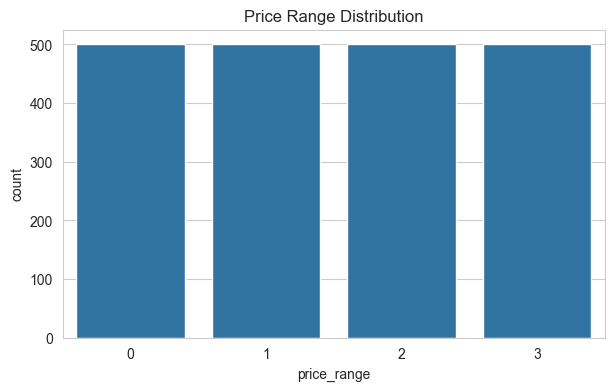

In [4]:
plt.figure(figsize=(7,4))
sns.countplot(x="price_range", data=df)
plt.title("Price Range Distribution")
plt.show()

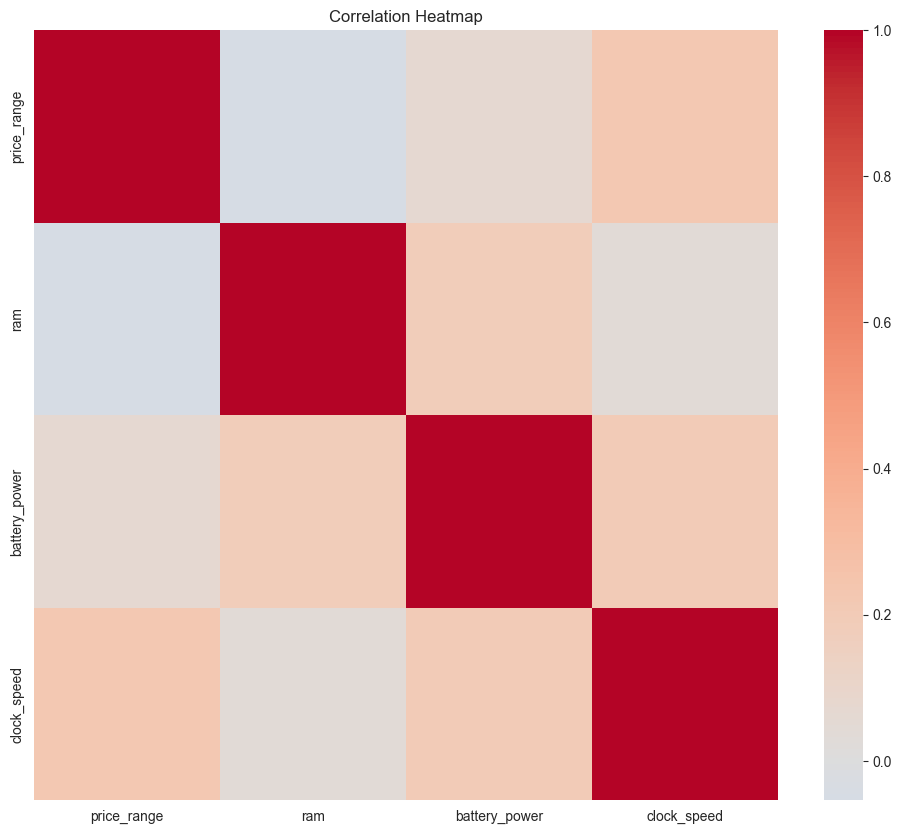

In [7]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

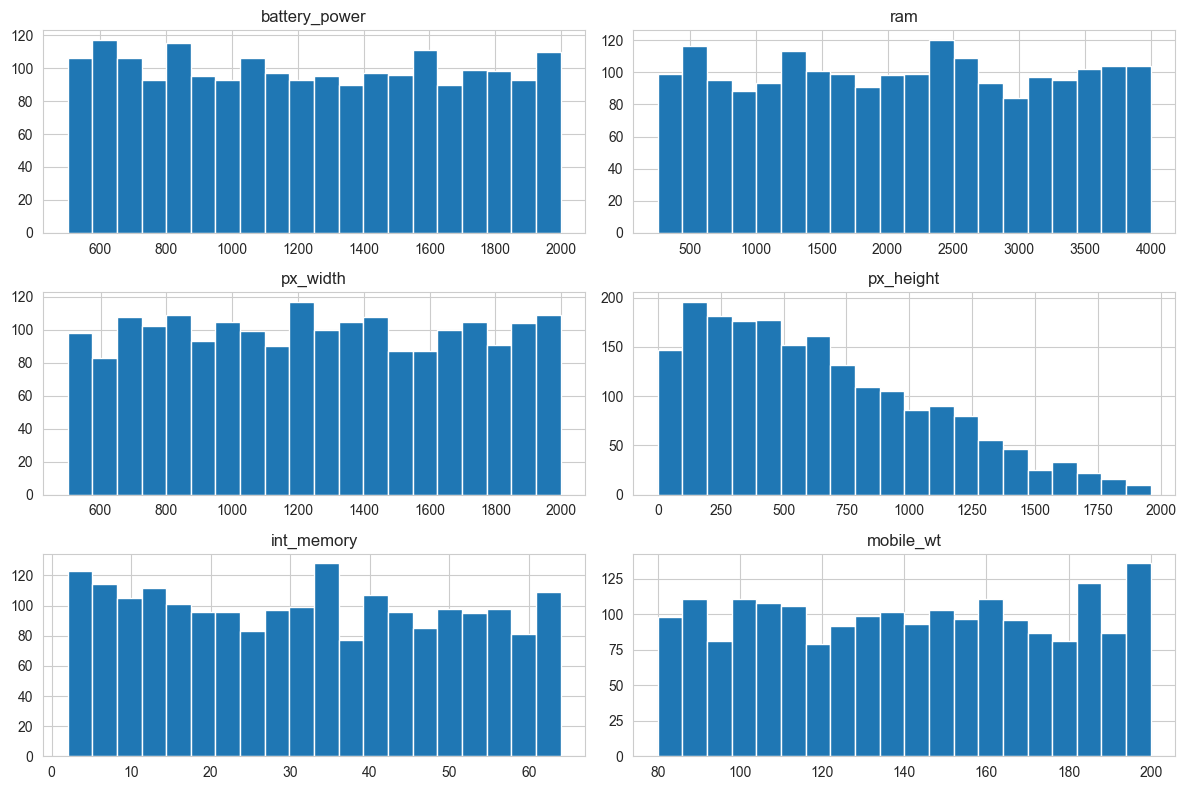

In [5]:
important_cols = ["battery_power", "ram", "px_width", "px_height", "int_memory", "mobile_wt"]
df[important_cols].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

In [6]:
X = df.drop(columns=["price_range"])
y = df["price_range"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1600, 20)
Test shape: (400, 20)


In [7]:
models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000))
    ]),
    "KNN": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(n_estimators=300, random_state=42))
    ]),
    "Extra Trees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesClassifier(n_estimators=300, random_state=42))
    ]),
    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingClassifier(random_state=42))
    ]),
    "SVC": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", random_state=42))
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
fitted_models = {}

for name, pipe in models.items():
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    rows.append({
        "Model": name,
        "CV Mean Accuracy": cv_scores.mean(),
        "CV Std": cv_scores.std(),
        "Test Accuracy": accuracy_score(y_test, pred),
        "Weighted F1": f1_score(y_test, pred, average="weighted")
    })

    fitted_models[name] = pipe

results_df = pd.DataFrame(rows).sort_values(
    ["Test Accuracy", "CV Mean Accuracy"], ascending=False
)
results_df

,Model,CV Mean Accuracy,CV Std,Test Accuracy,Weighted F1
0,Logistic Regression,0.948125,0.009803,0.9650,0.964986
5,Gradient Boosting,0.888125,0.019101,0.9125,0.912295
6,SVC,0.857500,0.010000,0.8950,0.895631
4,Extra Trees,0.863750,0.026487,0.8825,0.882235
3,Random Forest,0.871250,0.031275,0.8800,0.880180
2,Decision Tree,0.815625,0.012343,0.8300,0.830168
1,KNN,0.495625,0.031721,0.5000,0.505355


In [8]:
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
best_pred = best_model.predict(X_test)

print("Best model:", best_model_name)
print("Accuracy:", accuracy_score(y_test, best_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, best_pred))

Best model: Logistic Regression
Accuracy: 0.965

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.96      0.96      0.96       100
           2       0.95      0.94      0.94       100
           3       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400



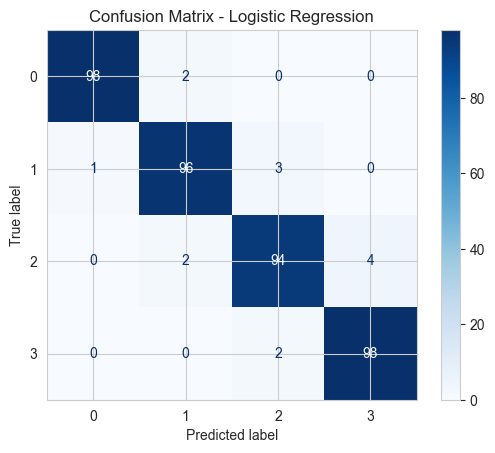

In [9]:
cm = confusion_matrix(y_test, best_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [10]:
estimator = best_model.named_steps["model"]

if hasattr(estimator, "feature_importances_"):
    importance = estimator.feature_importances_
else:
    perm = permutation_importance(
        best_model, X_test, y_test, n_repeats=10, random_state=42, scoring="accuracy"
    )
    importance = perm.importances_mean

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values("Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
13,ram,0.68800
0,battery_power,0.21675
12,px_width,0.11225
11,px_height,0.09550
8,mobile_wt,0.01350
17,three_g,0.00700
7,m_dep,0.00575
9,n_cores,0.00375
6,int_memory,0.00250
14,sc_h,0.00175


C:\Users\PRAGA\AppData\Local\Temp\ipykernel_7740\820155707.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(12), x="Importance", y="Feature", palette="viridis")


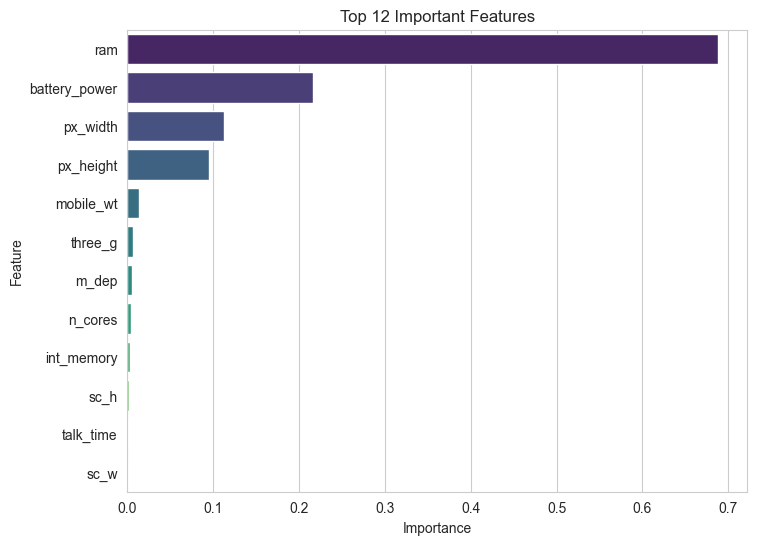

In [11]:
plt.figure(figsize=(8,6))
sns.barplot(data=feature_importance.head(12), x="Importance", y="Feature", palette="viridis")
plt.title("Top 12 Important Features")
plt.show()